# O4

CODE:

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

  WiFi Status BT Status  epsilon_r       Volume  
0       Fault     Fault       3.90  2634.316544  
1   

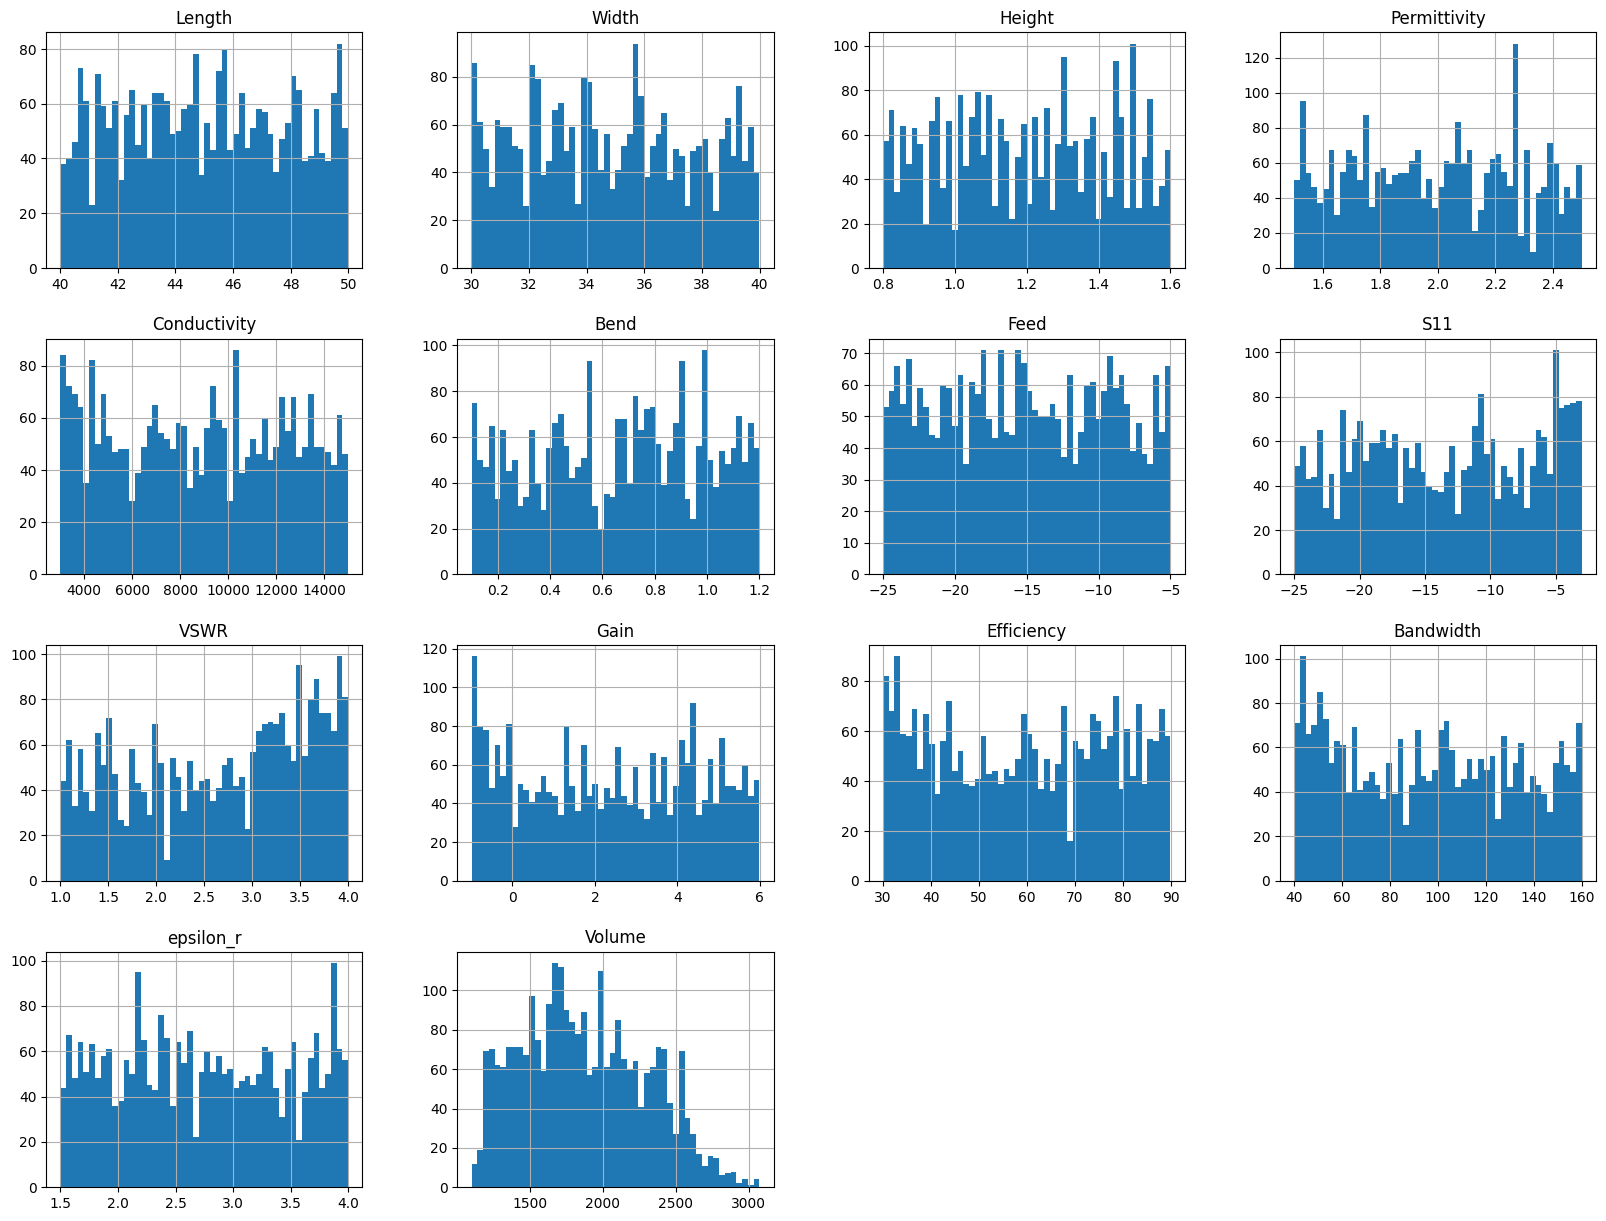

In [1]:
# Importing the data
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import os

Ant_dat = "dataset_with_volume2.csv"

# Load the data into a DataFrame
df = pd.read_csv(Ant_dat)


print(df.head()) #Prints the first five rows to get an idea of how the dataset looks
print(df.info()) #Prints some infomation about the data and their type (String/float)
print(df.describe()) #Prints count, mean, standard deviation, and the quatiles for each feature
df.hist(bins=50, figsize=(20,15))
plt.show()

This repport aims to build a model with the abilty to both determine whether or not, there is a fault in the bluetooth and/or wifi antenna system, and if there is, what type of fault is present. 
For the O4 project we have chosen to investigate the reliabilty of flexible and wearable antennas. With the rise of wearable technoligies like smartwatches there is a massive demand for reliable hardware cabable of suriving a bit of sweat or a knock. Our goal will be to develop a machine learning model able to predict imminent fault cases and be a part of the maintenance and detection system. The machine learning model should be a classifier able to ascertain whether or not the wifi and or bluetooth is failing and also classify which kind of fault is present. To train our model we have chosen [This data set from kaggle.com](https://www.kaggle.com/datasets/amineipad/antenna-performance-and-fault-detection-dataset?fbclid=IwY2xjawQffuJleHRuA2FlbQIxMQBzcnRjBmFwcF9pZAEwAAEeJ2UxEK4SsTF78Us3f-ALRqmDz68CFkv2aszLsnn0NTB3mq0-Kfri-Ghet-M_aem_khEFRjyx4IXRwn4GQIPcEw), it should work well due to its comprehensive feature list and a sample size of 2689, which is much more than is stated on the website, but alas is the true value of samples. The features include Length, Width, Height, Permittivity, Conductivity, and epsilon_r. Alongside these physical traits, the dataset captures critical radio frequency (RF) performance indicators like Return Loss (S11), Voltage Standing Wave Ratio (VSWR), Gain, Efficiency, and Bandwidth. From the description of the dataset: "Crucially, the dataset features explicit classifications for various environmental and physical fault conditions—such as Humidity/Sweat, Bending, Cracks, and Rupture/Coupure—and tracks their impact on the operational status of both WiFi and BT functionalities. It is an excellent resource for predictive maintenance, anomaly detection, and robust wearable antenna design using machine learning." Furthermore we as a group hope this project will enable us to obtain a deeper understanding of antenna perfomance and the parameters related to this. The data in this set was "collected through a series of controlled simulations and empirical measurements that emulate real-world conditions for wearable antennas. Various physical deformations and environmental stressors were applied to the antenna models, including bending at different radii, introducing structural cracks or ruptures, and simulating changes in dielectric properties due to humidity or sweat." So we should have in mind that the data probably represents cleaner versions of the faults and is limited to these kinds of fault, not entirely covering the real world in which the wearable antennas would exist. First, lets prepare the data for our model.

In [2]:
# Removing the wifi status and Bluetooth status columns to avoid leaking the answers
# Drop columns at index 14 and 15
ds = df.drop(df.columns[[14, 15]], axis=1)
print(ds.head())

   Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
0   46.72  38.62    1.46          1.51      12210.65  0.56 -10.27  -7.09   
1   40.32  36.17    1.30          1.61       9589.73  0.48 -17.33  -7.92   
2   43.84  35.89    1.17          1.53       4067.44  0.99 -11.95 -18.97   
3   43.77  39.46    1.26          1.88      13052.58  0.67 -10.07 -12.89   
4   46.48  39.66    1.30          2.44      12682.11  1.08 -17.57 -22.94   

   VSWR  Gain  Efficiency  Bandwidth       WiFi Fault        BT Fault  \
0  3.41  5.09       62.26     102.74           Cracks          Cracks   
1  2.47  5.17       66.61      96.06  Rupture_Coupure        No_Fault   
2  3.20  5.07       83.42     150.03          Bending  Strong_Flexion   
3  1.72  3.83       42.22      54.23      Body_Effect         Coupure   
4  1.44  3.48       77.39      93.00   Strong_Flexion        No_Fault   

   epsilon_r       Volume  
0       3.90  2634.316544  
1       3.03  1895.886720  
2       3.65  1840.8

In [3]:
# Splitting the data into features and target categories
target_cols = ['WiFi Fault', 'BT Fault']
y = ds[target_cols].copy()
X = ds.drop(target_cols, axis=1)

# Splitting into train and test sets, using stratify parameter for the y to ensure uniform distribution of faults
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)
print("X_train")
print(X_train.head())
print("y_train")
print(y_train.head())

target_encoder = OrdinalEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
print("y_train_encoded")
print(y_train_encoded[:,1])

X_train
      Length  Width  Height  Permittivity  Conductivity  Bend   Feed    S11  \
691    48.65  33.06    1.42          2.23       5418.60  0.42 -21.84 -11.52   
845    45.45  38.88    1.45          1.65       3111.05  0.53 -17.70 -24.38   
2682   45.61  30.12    1.39          1.84       3548.36  0.41 -20.20  -4.03   
1557   44.69  32.21    0.84          1.92       4435.72  0.11 -21.19  -3.70   
277    46.27  39.87    1.10          2.04      12281.38  0.26 -15.50  -6.19   

      VSWR  Gain  Efficiency  Bandwidth  epsilon_r       Volume  
691   1.75  5.46       42.19      69.46       3.10  2283.883980  
845   3.43  2.61       88.56     140.02       1.99  2562.289200  
2682  2.06  1.02       51.55     153.63       1.68  1909.544748  
1557  1.48  2.52       70.16      65.94       3.72  1209.150516  
277   3.64  2.69       77.88     104.07       3.05  2029.263390  
y_train
                    WiFi Fault           BT Fault
691                    Bending           No_Fault
845   Conduct

## Choice of ML algorithm
We have chosen to focus our efforts on the random forrest classifier, based on good past experiences combining fast computation times with good results. Furhter more we asses the random forrest model to be well equipped for multi label, multi output data, which is what we are dealing with. In fact the rfc does not require any parameters or data preprocessing to accept this data set. We have chosen to work with random_state=42 for all iterations to better compare scores and losses and eliminating 'luck' as a factor. Given that the dataset comes with the true fault categories we are in the realm of supervised learning and  multioutput classification as we want to figure out what fault type is present based on the features given. We chose rfc because it handles both numerical and categorical data well, requires minimal feature scaling, and is excellent at capturing non-linear relationships. Furthermore the rfc is much more robust than the single tree classifiers since it is the average of multiple models. On the other side the rfc is prone to overfitting and learning the noise from the dataset aswell so this must be kept in mind when tuning. 

## Data processing
As seen below and above, the dataset is first split into X and y matrices then split again into a training set and test set, setting aside $20\%$ for testing. Not only do we set aside 20\% we also ask the scikit learn function train_test_split to stratify with respect to the y data ensuring that even if the collecters of data has sorted the faults, this will not impact the training. Luckily they have not, but better to be too robust than fragile. If there were entries missing we would have to decide whether to fill them in with something like the mean of the other values or complety scrap either the feature(s) or the lacking samples. We expect to measure the goodness of the model using, accuracy, Jaccard score aswell as the F1 score to evalute the model. Allowing for a range from simple criterias to a deeper look at how well the model has learned. 

In [4]:
# Initiating the classifier
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X_train, y_train)
y_pred = forest_clf.predict(X_test)

print(y_test.shape)
print(y_pred.shape)

X_test_np = np.array(X_test)
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

# Flatten to 1D
X_test_flat = X_test_np.ravel()
X_train_flat = X_train_np.ravel()
y_train_flat = y_train_np.ravel()
y_test_flat = y_test_np.ravel()
y_pred_flat = y_pred_np.ravel()


acc_score = accuracy_score(y_test_flat, y_pred_flat)
print(f"Accuracy Score: {acc_score:.4f}")

j_score = jaccard_score(y_test_flat, y_pred_flat, average='macro')
print(f"Jaccard Score: {j_score:.4f}")

F1 = f1_score(y_test_flat, y_pred_flat, average='macro')
print(f"F1 Score: {F1:.4f}")

(538, 2)
(538, 2)
Accuracy Score: 0.8829
Jaccard Score: 0.8020
F1 Score: 0.8885


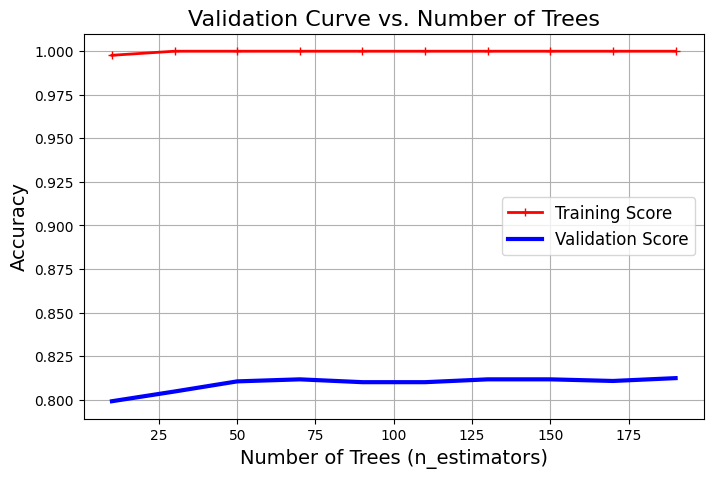

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_range = np.arange(10, 200, 20) # Tests 10, 30, 50... up to 190 trees

from sklearn.metrics import make_scorer
import numpy as np

# Define a custom scoring function that handles the 2D arrays
# This calculates the percentage of all individual labels that are correct AKA. accuracy
def All_D_accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

# Wrap it in make_scorer
custom_scorer = make_scorer(All_D_accuracy)

# Using validation_curve from scikit learn
train_scores, val_scores = validation_curve(
    forest_clf,
    X_train,
    y_train_encoded,
    param_name="n_estimators",
    param_range=param_range,
    cv=kf,
    scoring=custom_scorer,
    error_score="raise"
)

# Calculate the mean across all 5 cross-validation folds
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores_mean, "r-+", linewidth=2, label="Training Score")
plt.plot(param_range, val_scores_mean, "b-", linewidth=3, label="Validation Score")

plt.xlabel("Number of Trees (n_estimators)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Validation Curve vs. Number of Trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

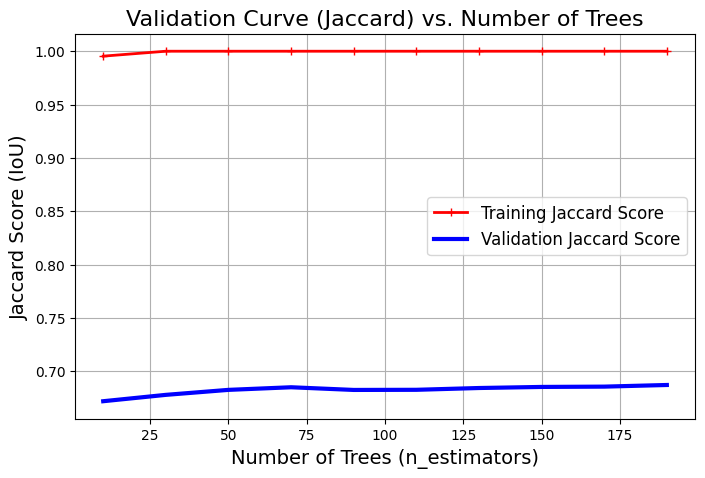

In [ ]:
def custom_jaccard_scorer(y_true, y_pred):
    y_true_flat = np.array(y_true).flatten()
    y_pred_flat = np.array(y_pred).flatten()
    return jaccard_score(y_true_flat, y_pred_flat, average='macro')

# Wrap it for scikit-learn
jaccard_custom = make_scorer(custom_jaccard_scorer)

train_scores, val_scores = validation_curve(
    forest_clf,
    X_train,
    y_train_encoded,
    param_name="n_estimators",
    param_range=param_range,
    cv=kf,
    scoring=jaccard_custom,
    error_score="raise"
)

# 4. Calculate Means
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# 5. Plotting
plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores_mean, "r-+", linewidth=2, label="Training Jaccard Score")
plt.plot(param_range, val_scores_mean, "b-", linewidth=3, label="Validation Jaccard Score")

plt.xlabel("Number of Trees (n_estimators)", fontsize=14)
plt.ylabel("Jaccard Score (IoU)", fontsize=14) # <-- Updated label
plt.title("Validation Curve (Jaccard) vs. Number of Trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## Validation before tuning hyperparameters
As seen above, letting all hyperparameters of the Randon Forest Classifier remain as standard values leads to a severe case of overfitting, although it does return a non-horrible validation accuracy, we see it even clearer when applying the jaccard score, which more heavily punishes the model for not having both predictions correct. Later we will look deeper into the hyper parameter tuning, but if we for now take a look at the parameter max_depth:

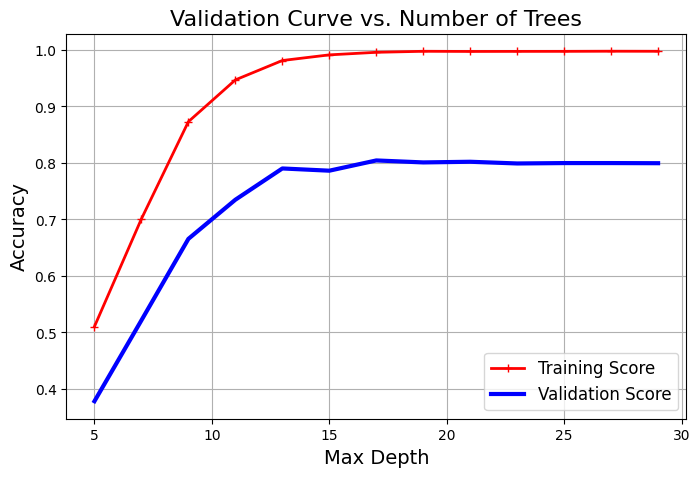

In [12]:
depth_range = np.arange(5, 30, 2)

forest_clf_n10 = RandomForestClassifier(n_estimators=10, random_state=42)

train_scores, val_scores = validation_curve(
    forest_clf_n10,
    X_train,
    y_train_encoded,
    param_name="max_depth",
    param_range=depth_range,
    cv=kf,
    scoring=custom_scorer,
    error_score="raise"
)

# Calculate the mean across all 5 cross-validation folds
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_scores_mean, "r-+", linewidth=2, label="Training Score")
plt.plot(depth_range, val_scores_mean, "b-", linewidth=3, label="Validation Score")

plt.xlabel("Max Depth", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Validation Curve vs. Number of Trees", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()